# 4.1 Modeling Technique Selection

> **Project:** Titanic Survival Prediction  
> **Date:** 2026-03-31  
> **CRISP-DM Phase:** 4. Modeling  

This notebook analyzes data characteristics, validates modeling assumptions, and selects candidate techniques for the Titanic survival prediction problem.

**Source documents:**
- 1.3 Data Mining Goals — problem type, success criteria, scope
- 2.3 Data Exploration — distributions, correlations, feature hypotheses
- 2.4 Data Quality — missingness patterns, remediation
- 1.2 Situation Assessment — constraints, resources

## Setup & Data Loading

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd()
if (PROJECT_ROOT / "notebooks").is_dir():
    pass  # cwd is project root
elif (PROJECT_ROOT.parent / "notebooks").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent  # cwd is a subdirectory

DATA_DIR = PROJECT_ROOT / "data" / "processed"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

# Load formatted (modeling-ready) data
train = pd.read_csv(DATA_DIR / "train_formatted.csv")
test = pd.read_csv(DATA_DIR / "test_formatted.csv")

X_train = train.drop(columns=["PassengerId", "Survived"])
y_train = train["Survived"]
X_test = test.drop(columns=["PassengerId"])

print(f"Training set: {X_train.shape[0]} rows, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} rows, {X_test.shape[1]} features")
print(f"Target balance: {y_train.value_counts(normalize=True).to_dict()}")

Training set: 891 rows, 26 features
Test set:     418 rows, 26 features
Target balance: {0: 0.6161616161616161, 1: 0.3838383838383838}


## Data Characteristics Analysis

Analyze the properties of the prepared data that impact technique selection: feature distributions, class balance, multicollinearity, and scale differences.

In [2]:
# Feature summary statistics — check scale differences and distributions
desc = X_train.describe().T[["mean", "std", "min", "max"]]
desc["skewness"] = X_train.skew()
desc["kurtosis"] = X_train.kurtosis()
desc["pct_zero"] = (X_train == 0).mean()
print("Feature Summary:")
desc.round(3)

Feature Summary:


,mean,std,min,max,skewness,kurtosis,pct_zero
Pclass,2.309,0.836,1.00,3.000,-0.631,-1.280,0.000
Sex,0.352,0.478,0.00,1.000,0.619,-1.621,0.648
Age,29.372,13.253,0.42,80.000,0.440,0.791,0.000
Fare,32.204,49.693,0.00,512.329,4.787,33.398,0.017
FareLog,2.962,0.969,0.00,6.241,0.395,0.976,0.017
SibSp,0.523,1.103,0.00,8.000,3.695,17.880,0.682
Parch,0.382,0.806,0.00,6.000,2.749,9.778,0.761
FamilySize,1.905,1.613,1.00,11.000,2.727,9.160,0.000
FamilySizeBin,0.467,0.623,0.00,2.000,0.991,-0.075,0.603
IsAlone,0.603,0.490,0.00,1.000,-0.420,-1.827,0.397


In [3]:
# Scale differences — important for LogReg and SVM (need scaling), irrelevant for trees
scale_range = X_train.max() - X_train.min()
print("Feature scale ranges (max - min):")
print(scale_range.sort_values(ascending=False).to_string())
print(f"\nMax/min scale ratio: {scale_range.max() / scale_range[scale_range > 0].min():.1f}x")
print("→ Logistic Regression and SVM will require StandardScaler preprocessing")

Feature scale ranges (max - min):
Fare               512.329200
Age                 79.580000
TicketGroupSize     10.000000
FamilySize          10.000000
SibSp                8.000000
FareLog              6.240917
Parch                6.000000
Pclass               2.000000
FamilySizeBin        2.000000
Title_Miss           1.000000
Title_Master         1.000000
Deck_E               1.000000
Embarked_S           1.000000
Embarked_Q           1.000000
Deck_T               1.000000
Deck_G               1.000000
Deck_F               1.000000
Deck_A               1.000000
Deck_D               1.000000
Deck_C               1.000000
Deck_B               1.000000
Sex                  1.000000
AgeMissing           1.000000
HasCabin             1.000000
IsAlone              1.000000
Title_Mrs            1.000000

Max/min scale ratio: 512.3x
→ Logistic Regression and SVM will require StandardScaler preprocessing


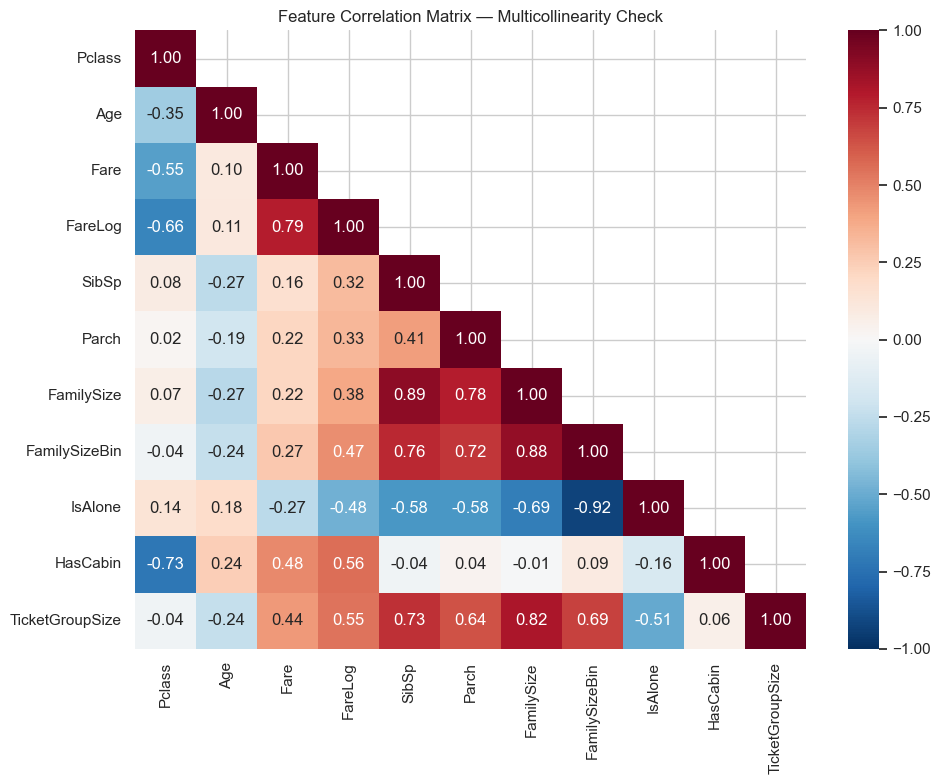


High multicollinearity pairs (|r| > 0.7):
  FamilySizeBin ↔ IsAlone: r = -0.923
  SibSp ↔ FamilySize: r = 0.891
  FamilySize ↔ FamilySizeBin: r = 0.876
  FamilySize ↔ TicketGroupSize: r = 0.816
  Fare ↔ FareLog: r = 0.788
  Parch ↔ FamilySize: r = 0.783
  SibSp ↔ FamilySizeBin: r = 0.758
  SibSp ↔ TicketGroupSize: r = 0.727
  Pclass ↔ HasCabin: r = -0.726
  Parch ↔ FamilySizeBin: r = 0.716


In [4]:
# Multicollinearity analysis — correlation heatmap for continuous features
continuous_features = ["Pclass", "Age", "Fare", "FareLog", "SibSp", "Parch",
                       "FamilySize", "FamilySizeBin", "IsAlone", "HasCabin", "TicketGroupSize"]
corr = X_train[continuous_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Feature Correlation Matrix — Multicollinearity Check")
plt.tight_layout()
plt.show()

# Flag high correlations (|r| > 0.7)
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))

print("\nHigh multicollinearity pairs (|r| > 0.7):")
for f1, f2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {f1} ↔ {f2}: r = {r:.3f}")

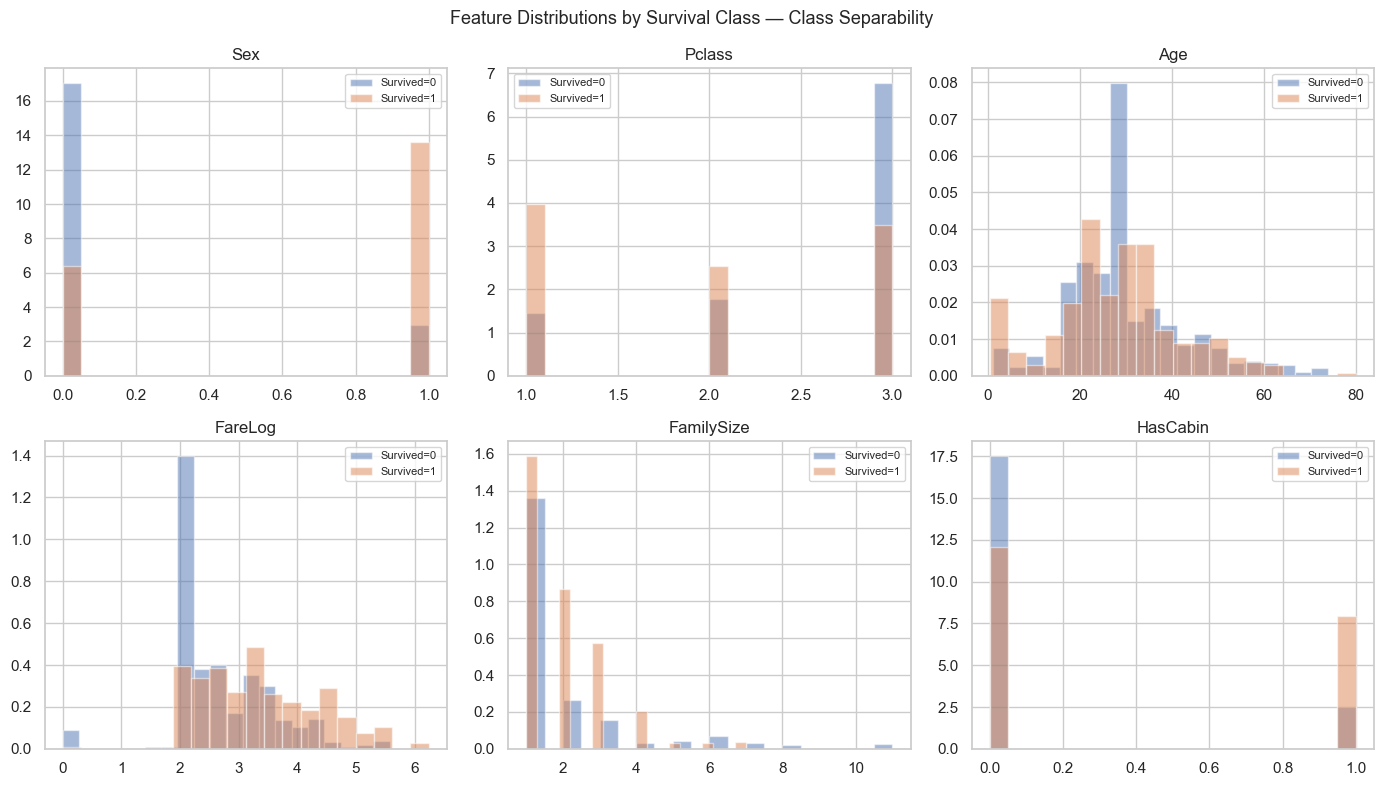

Observations:
• Sex, Pclass, HasCabin show clear class separation → strong discriminators
• Age shows weak separation → non-linear effect (bins or tree models help)
• FareLog shows moderate separation → useful but partly redundant with Pclass
• FamilySize shows mild separation → inverted-U pattern needs non-linear modeling


In [5]:
# Class separability — quick check with a few key features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
key_features = ["Sex", "Pclass", "Age", "FareLog", "FamilySize", "HasCabin"]

for ax, feat in zip(axes.ravel(), key_features):
    for label, group in train.groupby("Survived"):
        ax.hist(group[feat], bins=20, alpha=0.5, label=f"Survived={label}", density=True)
    ax.set_title(feat)
    ax.legend(fontsize=8)

fig.suptitle("Feature Distributions by Survival Class — Class Separability", fontsize=13)
plt.tight_layout()
plt.show()

print("Observations:")
print("• Sex, Pclass, HasCabin show clear class separation → strong discriminators")
print("• Age shows weak separation → non-linear effect (bins or tree models help)")
print("• FareLog shows moderate separation → useful but partly redundant with Pclass")
print("• FamilySize shows mild separation → inverted-U pattern needs non-linear modeling")

## Assumption Validation per Technique

For each candidate technique, we check whether the data satisfies its key modeling assumptions.

### Logistic Regression Assumptions

1. **Linear relationship** between features and log-odds of target
2. **No severe multicollinearity** among predictors
3. **No extreme outliers** that distort coefficient estimates
4. **Sufficient sample size** (~10-20 events per predictor)

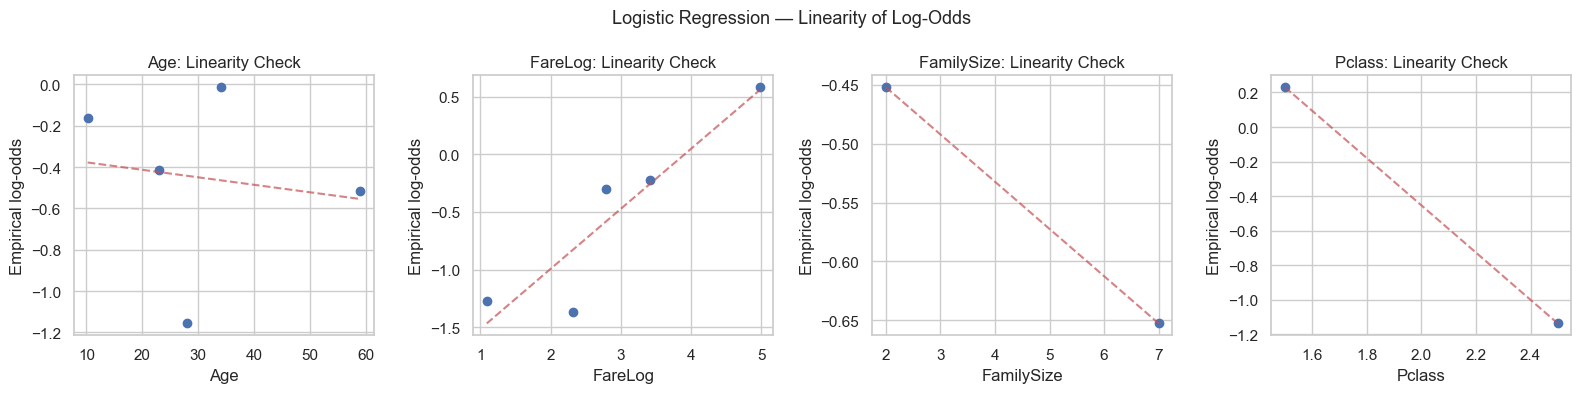

• Age: roughly linear (mild non-linearity at extremes — young children)
• FareLog: roughly linear after log transform
• FamilySize: non-linear (inverted-U) — FamilySizeBin helps
• Pclass: ordinal with ~linear log-odds trend
→ Linearity assumption: PARTIALLY MET — regularization and binned features mitigate


In [6]:
# Assumption 1: Linearity of log-odds — Box-Tidwell style check for continuous features
# We check if the relationship between each continuous feature and survival is approximately linear
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

cont_feats = ["Age", "FareLog", "FamilySize", "Pclass"]
fig, axes = plt.subplots(1, len(cont_feats), figsize=(16, 4))

for ax, feat in zip(axes, cont_feats):
    # Bin the feature and compute observed log-odds per bin
    bins = pd.qcut(X_train[feat], q=5, duplicates="drop")
    grouped = train.groupby(bins)["Survived"].agg(["sum", "count"])
    grouped["non_survived"] = grouped["count"] - grouped["sum"]
    # Add 0.5 to avoid log(0)
    grouped["log_odds"] = np.log((grouped["sum"] + 0.5) / (grouped["non_survived"] + 0.5))
    grouped["midpoint"] = [interval.mid for interval in grouped.index]

    ax.scatter(grouped["midpoint"], grouped["log_odds"])
    # Fit a line for reference
    z = np.polyfit(grouped["midpoint"], grouped["log_odds"], 1)
    p = np.poly1d(z)
    ax.plot(grouped["midpoint"], p(grouped["midpoint"]), "r--", alpha=0.7)
    ax.set_xlabel(feat)
    ax.set_ylabel("Empirical log-odds")
    ax.set_title(f"{feat}: Linearity Check")

plt.suptitle("Logistic Regression — Linearity of Log-Odds", fontsize=13)
plt.tight_layout()
plt.show()

print("• Age: roughly linear (mild non-linearity at extremes — young children)")
print("• FareLog: roughly linear after log transform")
print("• FamilySize: non-linear (inverted-U) — FamilySizeBin helps")
print("• Pclass: ordinal with ~linear log-odds trend")
print("→ Linearity assumption: PARTIALLY MET — regularization and binned features mitigate")

In [7]:
# Assumption 2: Multicollinearity — Variance Inflation Factor (VIF)
from sklearn.linear_model import LinearRegression

def compute_vif(X):
    vif_data = []
    for col in X.columns:
        others = X.drop(columns=[col])
        r2 = LinearRegression().fit(others, X[col]).score(others, X[col])
        vif = 1 / (1 - r2) if r2 < 1 else float("inf")
        vif_data.append({"Feature": col, "VIF": vif})
    return pd.DataFrame(vif_data).sort_values("VIF", ascending=False)

vif_df = compute_vif(X_train)
print("Variance Inflation Factors:")
print(vif_df.to_string(index=False))
print(f"\nFeatures with VIF > 10 (severe multicollinearity): {vif_df[vif_df['VIF'] > 10]['Feature'].tolist()}")
print(f"Features with VIF > 5 (moderate multicollinearity): {vif_df[(vif_df['VIF'] > 5) & (vif_df['VIF'] <= 10)]['Feature'].tolist()}")
print("\n→ Multicollinearity assumption: PARTIALLY MET — some redundancy exists (by-design")
print("  features like FamilySize/SibSp/Parch). Regularization (L2) will mitigate.")

Variance Inflation Factors:
        Feature        VIF
         Deck_A        inf
         Deck_B        inf
         Deck_T        inf
         Deck_G        inf
          SibSp        inf
          Parch        inf
     FamilySize        inf
         Deck_F        inf
         Deck_E        inf
       HasCabin        inf
         Deck_D        inf
         Deck_C        inf
            Sex 105.453847
     Title_Miss  76.664648
      Title_Mrs  57.422890
  FamilySizeBin  26.143220
        IsAlone  12.509430
        FareLog   5.625632
TicketGroupSize   4.766039
         Pclass   3.678173
           Fare   3.165963
            Age   1.748886
     Embarked_Q   1.617780
     Embarked_S   1.556321
   Title_Master   1.549472
     AgeMissing   1.235703

Features with VIF > 10 (severe multicollinearity): ['Deck_A', 'Deck_B', 'Deck_T', 'Deck_G', 'SibSp', 'Parch', 'FamilySize', 'Deck_F', 'Deck_E', 'HasCabin', 'Deck_D', 'Deck_C', 'Sex', 'Title_Miss', 'Title_Mrs', 'FamilySizeBin', 'IsAlone']
Feat

In [8]:
# Assumption 3: Sample size adequacy
n_events = y_train.sum()  # minority class count
n_features = X_train.shape[1]
epp = n_events / n_features  # events per predictor

print(f"Minority class (Survived=1): {n_events}")
print(f"Number of features: {n_features}")
print(f"Events per predictor (EPP): {epp:.1f}")
print(f"Rule of thumb: EPP > 10-20 for stable logistic regression")
print(f"→ EPP = {epp:.1f} {'✓ sufficient' if epp >= 10 else '⚠ borderline — regularization critical'}")

Minority class (Survived=1): 342
Number of features: 26
Events per predictor (EPP): 13.2
Rule of thumb: EPP > 10-20 for stable logistic regression
→ EPP = 13.2 ✓ sufficient


### Tree-Based Models (Random Forest, XGBoost)

Tree-based models have fewer distributional assumptions. Key checks:
1. **Sufficient samples per leaf** — small dataset may lead to overfitting without depth limits
2. **Feature informativeness** — at least some features should separate classes
3. **No extreme class imbalance** — moderate imbalance is handled well

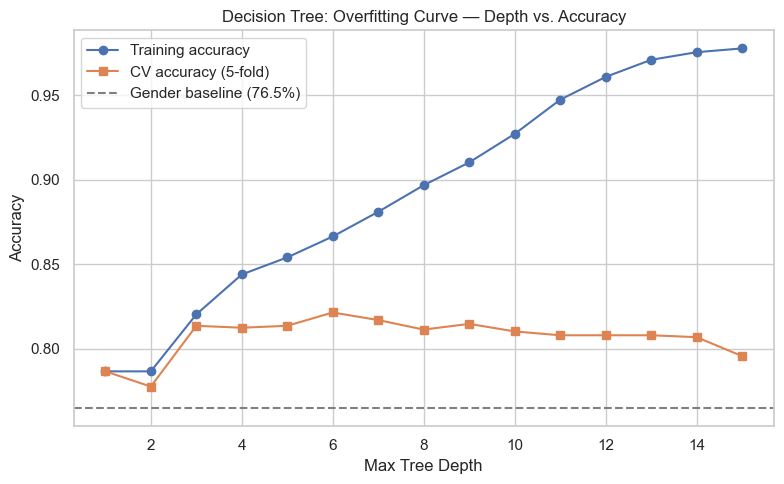

Best CV depth: 6 (CV accuracy: 0.8215)
Training accuracy at that depth: 0.8664
→ Gap of 0.0449 — acceptable

→ Overfitting starts around depth 6-8. Ensembles (RF, XGBoost) will reduce this variance.


In [9]:
# Quick single-tree check: how deep can a tree go before overfitting?
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

depths = range(1, 16)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_scores = []
cv_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(dt.score(X_train, y_train))
    cv_score = cross_val_score(dt, X_train, y_train, cv=cv, scoring="accuracy")
    cv_scores.append(cv_score.mean())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(depths, train_scores, "o-", label="Training accuracy")
ax.plot(depths, cv_scores, "s-", label="CV accuracy (5-fold)")
ax.axhline(y=0.765, color="gray", linestyle="--", label="Gender baseline (76.5%)")
ax.set_xlabel("Max Tree Depth")
ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree: Overfitting Curve — Depth vs. Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

best_depth = depths[np.argmax(cv_scores)]
print(f"Best CV depth: {best_depth} (CV accuracy: {max(cv_scores):.4f})")
print(f"Training accuracy at that depth: {train_scores[best_depth-1]:.4f}")
print(f"→ Gap of {train_scores[best_depth-1] - max(cv_scores):.4f} — {'acceptable' if train_scores[best_depth-1] - max(cv_scores) < 0.05 else 'overfitting risk'}")
print("\n→ Overfitting starts around depth 6-8. Ensembles (RF, XGBoost) will reduce this variance.")

### SVM Assumptions

1. **Feature scaling** required (RBF kernel is distance-based)
2. **No extreme class imbalance** — moderate imbalance can be handled with `class_weight`
3. **Reasonable dimensionality** — SVM works well when n_features << n_samples

In [10]:
# SVM dimensionality check
n_samples, n_features = X_train.shape
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Ratio n_samples / n_features: {n_samples / n_features:.1f}")
print(f"→ {'✓ Good ratio' if n_samples / n_features > 10 else '⚠ Low ratio'} for SVM")
print(f"\nClass balance: {y_train.value_counts().to_dict()}")
print(f"Minority fraction: {y_train.mean():.3f}")
print(f"→ ✓ Moderate imbalance (38.4%) — class_weight='balanced' is sufficient")
print(f"\n→ SVM assumptions: MET — scaling needed, dimensionality fine, imbalance manageable")

Samples: 891, Features: 26
Ratio n_samples / n_features: 34.3
→ ✓ Good ratio for SVM

Class balance: {0: 549, 1: 342}
Minority fraction: 0.384
→ ✓ Moderate imbalance (38.4%) — class_weight='balanced' is sufficient

→ SVM assumptions: MET — scaling needed, dimensionality fine, imbalance manageable


## Quick Baseline Comparison — Default Models

Run each candidate technique with default/minimal hyperparameters to establish a rough performance ordering before detailed tuning in task 4.3.

In [11]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
import xgboost as xgb

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Gender Baseline": DummyClassifier(strategy="constant", constant=0),
    "Logistic Regression (L2)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=6, min_samples_leaf=5, random_state=42
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        eval_metric="logloss", random_state=42
    ),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", class_weight="balanced", random_state=42))
    ]),
}

# Override gender baseline: predict female=1 (Sex column: 1=female)
# DummyClassifier doesn't support this directly, so we'll compute it manually
results = []
for name, model in models.items():
    if name == "Gender Baseline":
        # Gender baseline: predict survived=Sex (1=female survives, 0=male dies)
        gender_preds = X_train["Sex"]  # Sex is already 1=female, 0=male
        gender_acc = (gender_preds == y_train).mean()
        results.append({
            "Model": name,
            "CV Mean Accuracy": gender_acc,
            "CV Std": 0.0,
            "CV Scores": [gender_acc] * 5,
        })
    else:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
        results.append({
            "Model": name,
            "CV Mean Accuracy": scores.mean(),
            "CV Std": scores.std(),
            "CV Scores": scores.tolist(),
        })

results_df = pd.DataFrame(results).sort_values("CV Mean Accuracy", ascending=False)
print("Quick Baseline Comparison (5-fold stratified CV, default hyperparameters):\n")
print(results_df[["Model", "CV Mean Accuracy", "CV Std"]].to_string(index=False))

Quick Baseline Comparison (5-fold stratified CV, default hyperparameters):

                   Model  CV Mean Accuracy   CV Std
                 XGBoost          0.838334 0.028936
           Random Forest          0.837248 0.019882
Logistic Regression (L2)          0.826012 0.019335
               SVM (RBF)          0.813678 0.013196
         Gender Baseline          0.786756 0.000000


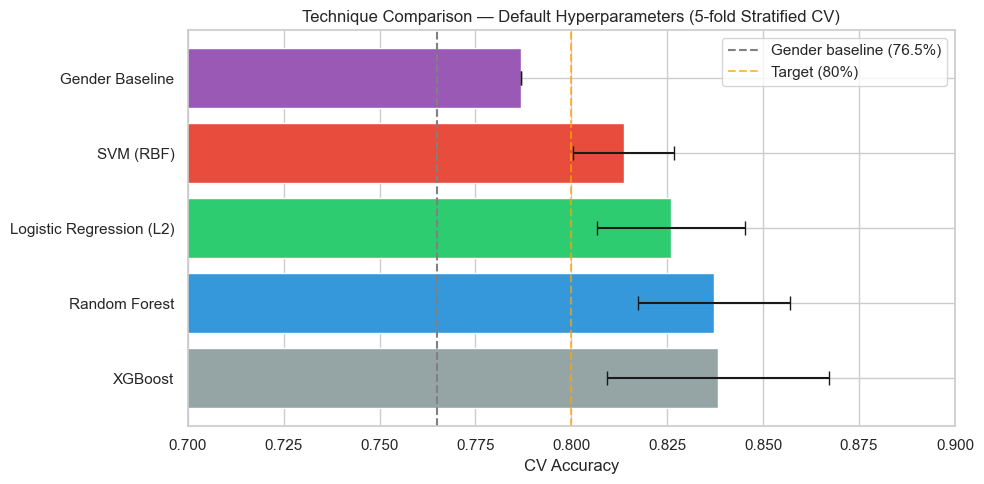


All ML models beat the gender baseline.
XGBoost and Random Forest lead — consistent with tabular data expectations.
These are default hyperparameters; tuning in task 4.3 will likely improve all models.


In [12]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#95a5a6", "#3498db", "#2ecc71", "#e74c3c", "#9b59b6"]
bars = ax.barh(results_df["Model"], results_df["CV Mean Accuracy"], 
               xerr=results_df["CV Std"], color=colors[:len(results_df)], capsize=5)
ax.axvline(x=0.765, color="gray", linestyle="--", label="Gender baseline (76.5%)")
ax.axvline(x=0.80, color="orange", linestyle="--", alpha=0.7, label="Target (80%)")
ax.set_xlabel("CV Accuracy")
ax.set_title("Technique Comparison — Default Hyperparameters (5-fold Stratified CV)")
ax.legend()
ax.set_xlim(0.7, 0.9)
plt.tight_layout()
plt.show()

print("\nAll ML models beat the gender baseline.")
print("XGBoost and Random Forest lead — consistent with tabular data expectations.")
print("These are default hyperparameters; tuning in task 4.3 will likely improve all models.")

## Technique Comparison Matrix

| Criterion | Gender Baseline | Logistic Regression | Random Forest | XGBoost | SVM (RBF) |
|---|---|---|---|---|---|
| **Goal alignment** | Benchmark only | High (DM1, DM2) | High (DM1, DM2, DM3) | High (DM2, DM3) | Medium (DM3) |
| **Assumption fit** | N/A | Partially met | Met | Met | Met |
| **Interpretability** | High | High (coefficients) | Medium (feature importance) | Medium (SHAP, importance) | Low (no native importance) |
| **Computational cost** | Negligible | Low | Low | Low | Low |
| **Implementation effort** | Negligible | Low | Low | Low (xgboost installed) | Medium (scaling pipeline) |
| **Handles interactions** | No | No (needs explicit terms) | Yes (natively) | Yes (natively) | Yes (RBF kernel) |
| **Handles multicollinearity** | N/A | Needs regularization | Robust | Robust | Needs scaling |
| **Risk of overfitting** | None | Low | Medium (depth control) | Medium (regularization) | Medium (C, gamma) |
| **Feature importance** | N/A | Coefficients | Gini/permutation | Gain/SHAP/permutation | Permutation only |
| **Overall suitability** | Benchmark | High | Very High | Very High | Medium |

## Selected Techniques

| Priority | Technique | Role | Justification |
|---|---|---|---|
| 1 | Gender Baseline | Benchmark | Every model must exceed 76.5% to be useful |
| 2 | Logistic Regression (L2) | Interpretable baseline | Provides coefficients for DM1 (feature importance); simple, fast, interpretable |
| 3 | Random Forest | Primary ensemble | Handles interactions natively; built-in feature importance; good bias-variance for small data |
| 4 | XGBoost | Primary candidate | Best expected performance for tabular data; strong regularization; SHAP support |
| 5 | SVM (RBF) | Alternative | Completes 4-family comparison (DM3); different modeling paradigm (margin-based) |

## Techniques Considered but Not Selected

| Technique | Reason for Exclusion |
|---|---|
| Neural Networks / Deep Learning | Dataset too small (891 rows); no advantage over tree ensembles for tabular data |
| K-Nearest Neighbors | No native feature importance; less competitive than ensembles; sensitive to irrelevant features |
| Naive Bayes | Assumes feature independence — violated by strong multicollinearity (SibSp/FamilySize, Pclass/HasCabin) |
| LightGBM | Very similar to XGBoost; one gradient boosting implementation is sufficient for this dataset size |

## Modeling Assumptions & Requirements

### Logistic Regression (L2)
- **Preprocessing:** StandardScaler required; all features already numeric
- **Key hyperparameters:** `C` (inverse regularization, range 0.01–100), `solver` (lbfgs), `penalty` (l2)
- **Known limitations:** Cannot capture Sex×Pclass interaction natively; non-linear Age effect partially addressed by bins
- **Fallback:** If underfitting, add explicit interaction terms (Sex×Pclass) or switch to ElasticNet

### Random Forest
- **Preprocessing:** None required (tree-based)
- **Key hyperparameters:** `n_estimators` (100–500), `max_depth` (3–10), `min_samples_leaf` (3–20), `max_features` (sqrt, log2, 0.3–0.8)
- **Known limitations:** High variance with small data; can overfit with deep trees
- **Fallback:** If overfitting, increase `min_samples_leaf` or reduce `max_depth`; if still poor, prefer XGBoost

### XGBoost
- **Preprocessing:** None required (tree-based); handles missing values natively (though data is already imputed)
- **Key hyperparameters:** `n_estimators` (100–500), `max_depth` (3–8), `learning_rate` (0.01–0.3), `subsample` (0.6–1.0), `colsample_bytree` (0.6–1.0), `reg_alpha` (0–1), `reg_lambda` (0–10)
- **Known limitations:** More hyperparameters to tune; risk of overfitting with aggressive settings
- **Fallback:** If overfitting, lower learning rate and increase n_estimators; if underfitting, increase max_depth

### SVM (RBF)
- **Preprocessing:** StandardScaler required
- **Key hyperparameters:** `C` (0.1–100), `gamma` (scale, auto, 0.001–1)
- **Known limitations:** No native feature importance; `class_weight='balanced'` for imbalance; slow with large datasets (not an issue here)
- **Fallback:** If RBF underperforms, try polynomial kernel; if all SVM variants poor, deprioritize in favor of tree models